# ⚽ Premier League — Over/Under 2.5 Goals Classifier
**Data sources:** football-data.org (free API) · No scraping · No Cloudflare  
**Models:** Logistic Regression · Gradient Boosting · XGBoost (stacked ensemble)  
**Outputs:** Match outcome + Over/Under prediction card with visualizations

---
> ⚠️ Replace `YOUR_API_KEY` in the Config cell before running.  
> Run cells top-to-bottom. First-time data fetch takes ~2 min (rate limit).


In [3]:
# ── Imports ────────────────────────────────────────────────────────────────────
import warnings, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import xgboost as xgb

from scipy.stats import poisson
from sklearn.calibration import calibration_curve
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, brier_score_loss)
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
print("✅ Libraries loaded")


✅ Libraries loaded


In [17]:
# ══════════════════════════════════════════════════════════════
# CONFIG — edit here only
# ══════════════════════════════════════════════════════════════
API_KEY  = "YOUR_API_KEY"          # ← football-data.org free key
BASE     = "https://api.football-data.org/v4"
HEADERS  = {"X-Auth-Token": "API-KEY"}
COMP     = "PL"                    # Premier League
SEASONS  = [2023,2024,2025]
N_FORM   = 5                       # rolling window
META_COLS = {"over25","winner","date","home","away","total_goals"}
print(f"Config set — Competition: {COMP} | Seasons: {SEASONS} | Form window: {N_FORM}")


Config set — Competition: PL | Seasons: [2023, 2024, 2025] | Form window: 5


## 📥 Step 1 — Fetch Data

In [23]:
def api_get(endpoint: str) -> dict:
    r = requests.get(f"{BASE}{endpoint}", headers=HEADERS, timeout=10)
    r.raise_for_status()
    time.sleep(7)
    return r.json()

def get_matches(season: int) -> pd.DataFrame:
    data = api_get(f"/competitions/{COMP}/matches?season={season}")
    rows = []
    for m in data["matches"]:
        rows.append({
            "date":        m["utcDate"][:10],
            "matchday":    m["matchday"],
            "home":        m["homeTeam"]["name"],
            "away":        m["awayTeam"]["name"],
            "status":      m["status"],
            "home_score":  m["score"]["fullTime"]["home"],
            "away_score":  m["score"]["fullTime"]["away"],
            "winner":      m["score"]["winner"],
        })
    return pd.DataFrame(rows)

def get_standings(season: int = 2024) -> pd.DataFrame:
    data = api_get(f"/competitions/{COMP}/standings?season={season}")
    rows = []
    for e in data["standings"][0]["table"]:
        rows.append({
            "pos": e["position"], "team": e["team"]["name"],
            "played": e["playedGames"], "won": e["won"],
            "draw": e["draw"], "lost": e["lost"],
            "gf": e["goalsFor"], "ga": e["goalsAgainst"],
            "gd": e["goalDifference"], "points": e["points"],
            "form": e.get("form",""),
        })
    return pd.DataFrame(rows)

def build_dataset(seasons: list) -> pd.DataFrame:
    all_matches = []
    for s in seasons:
        print(f"  Fetching {COMP} {s}...")
        df = get_matches(s)
        all_matches.append(df)
    return pd.concat(all_matches, ignore_index=True)

def get_season(date) -> str:
    """
    Aug–May = one football season.
    Aug 2021 → 2021-22,  Mar 2022 → 2021-22,  Aug 2022 → 2022-23
    """
    if date.month >= 8:
        return f"{date.year}-{str(date.year + 1)[-2:]}"
    else:
        return f"{date.year - 1}-{str(date.year)[-2:]}"
# ── OPTION A: Fetch fresh (uncomment) ──────────────────────────\
df_raw = build_dataset(SEASONS)
df_raw.to_csv("pl_matchesall.csv", index=False)
print(f"✅ {len(df_raw)} matches saved")

# ── OPTION B: Load from existing CSV ──────────────────────────
#df_raw = pd.read_csv("pl_matches.csv")
#print(f"✅ Loaded {len(df_raw)} matches from pl_matches.csv")
#print(df_raw.head(3).to_string(index=False))


  Fetching PL 2023...
  Fetching PL 2024...
  Fetching PL 2025...
✅ 1140 matches saved


## 🔧 Step 2 — Preprocessing

In [24]:
df = df_raw[df_raw["status"] == "FINISHED"].copy()
df["date"]        = pd.to_datetime(df["date"])
df["total_goals"] = df["home_score"] + df["away_score"]
df["over25"]      = (df["total_goals"] > 2.5).astype(int)
df["season"] = df["date"].apply(get_season)

print(f"Finished matches : {len(df)}")
print(f"Over 2.5         : {df['over25'].mean():.1%}")
print(f"Under 2.5        : {(1 - df['over25'].mean()):.1%}")
print(f"Avg goals/game   : {df['total_goals'].mean():.2f}")
print(f"Seasons          : {df['season'].unique().tolist()}")


Finished matches : 1099
Over 2.5         : 58.7%
Under 2.5        : 41.3%
Avg goals/game   : 2.99
Seasons          : ['2023-24', '2024-25', '2025-26']


## 📊 Step 3 — Exploratory Analysis

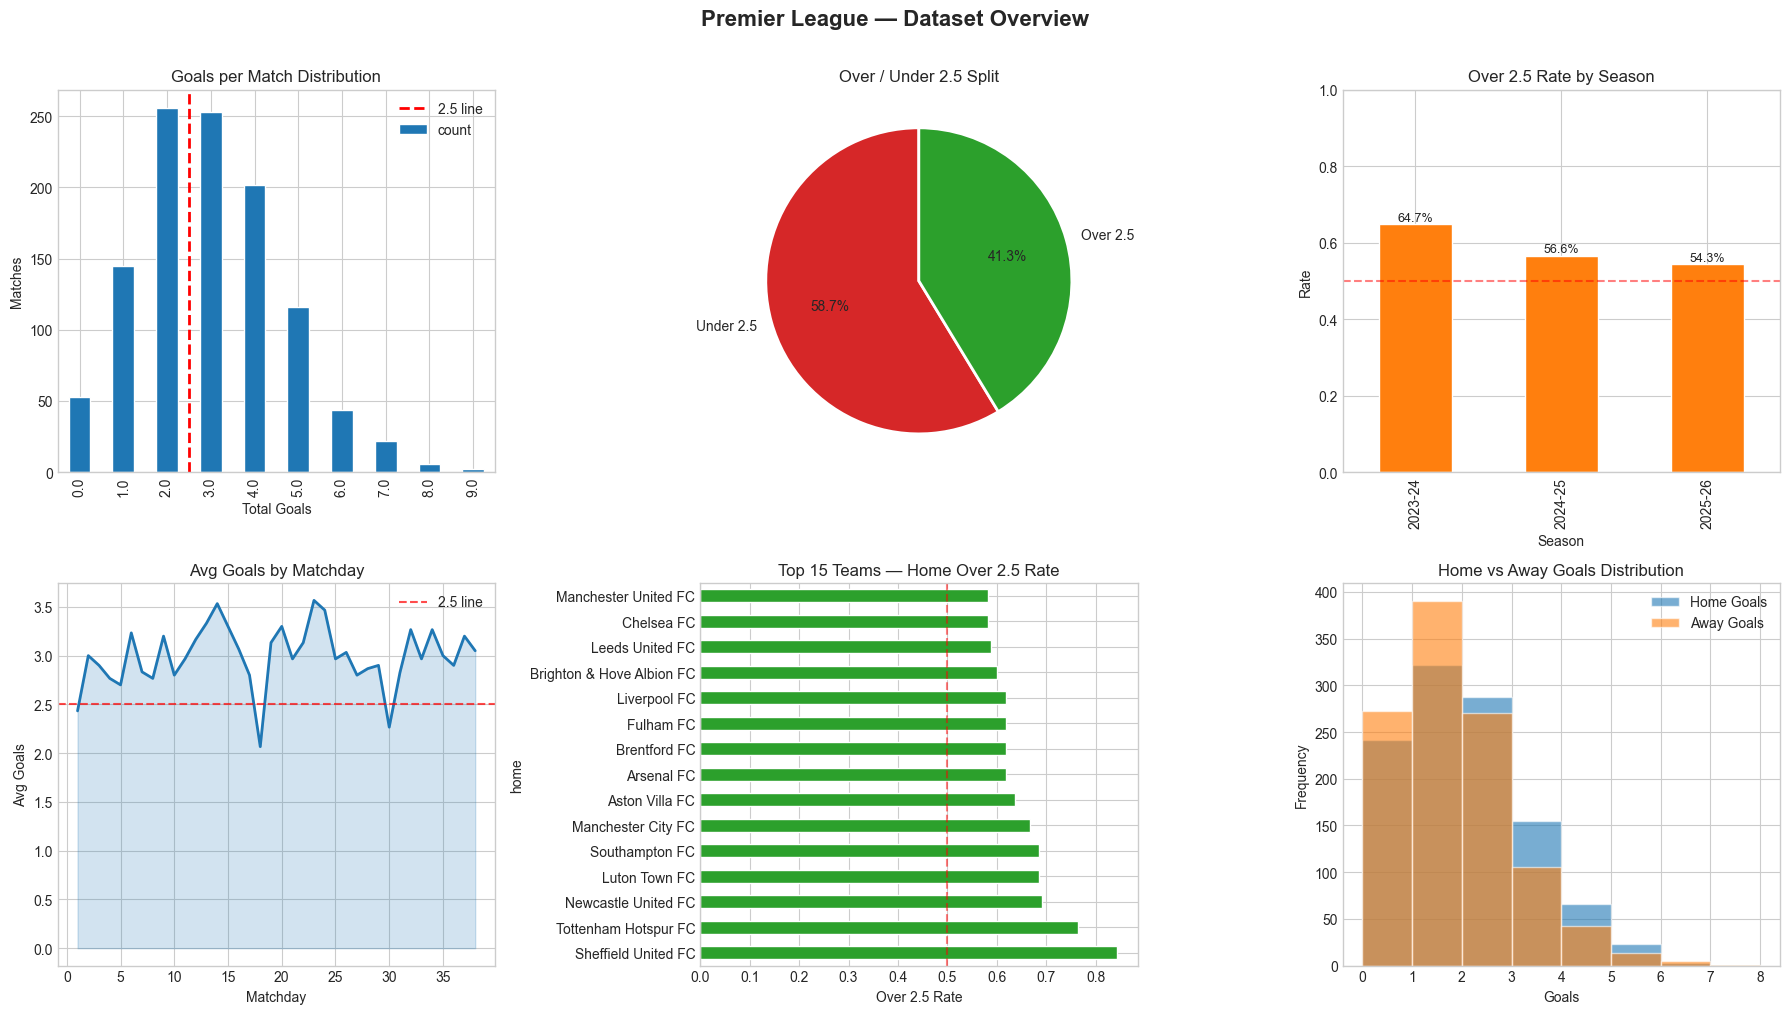

✅ EDA plots saved


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Premier League — Dataset Overview", fontsize=16, fontweight="bold", y=1.01)

# 1. Goals distribution
ax = axes[0, 0]
df["total_goals"].value_counts().sort_index().plot(kind="bar", ax=ax, color=PALETTE[0], edgecolor="white")
ax.axvline(x=2.5, color="red", linestyle="--", linewidth=2, label="2.5 line")
ax.set_title("Goals per Match Distribution"); ax.set_xlabel("Total Goals"); ax.set_ylabel("Matches")
ax.legend()

# 2. Over/Under pie
ax = axes[0, 1]
counts = df["over25"].value_counts()
ax.pie(counts, labels=["Under 2.5", "Over 2.5"], autopct="%1.1f%%",
       colors=[PALETTE[3], PALETTE[2]], startangle=90,
       wedgeprops={"edgecolor":"white","linewidth":2})
ax.set_title("Over / Under 2.5 Split")

# 3. Over 2.5 rate by season
ax = axes[0, 2]
season_over = df.groupby("season")["over25"].mean()
season_over.plot(kind="bar", ax=ax, color=PALETTE[1], edgecolor="white")
ax.set_title("Over 2.5 Rate by Season"); ax.set_xlabel("Season"); ax.set_ylabel("Rate")
ax.set_ylim(0, 1); ax.axhline(0.5, color="red", linestyle="--", alpha=0.5)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}", (p.get_x()+p.get_width()/2, p.get_height()+0.01),
                ha="center", fontsize=9)

# 4. Avg goals by matchday
ax = axes[1, 0]
md_goals = df.groupby("matchday")["total_goals"].mean()
ax.plot(md_goals.index, md_goals.values, color=PALETTE[0], linewidth=2)
ax.fill_between(md_goals.index, md_goals.values, alpha=0.2, color=PALETTE[0])
ax.axhline(2.5, color="red", linestyle="--", alpha=0.7, label="2.5 line")
ax.set_title("Avg Goals by Matchday"); ax.set_xlabel("Matchday"); ax.set_ylabel("Avg Goals")
ax.legend()

# 5. Top 15 Over 2.5 teams (home)
ax = axes[1, 1]
home_over = df.groupby("home")["over25"].mean().nlargest(15)
home_over.plot(kind="barh", ax=ax, color=PALETTE[2], edgecolor="white")
ax.set_title("Top 15 Teams — Home Over 2.5 Rate")
ax.set_xlabel("Over 2.5 Rate"); ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)

# 6. Home vs Away goals
ax = axes[1, 2]
ax.hist(df["home_score"], bins=range(0,9), alpha=0.6, label="Home Goals", color=PALETTE[0], edgecolor="white")
ax.hist(df["away_score"], bins=range(0,9), alpha=0.6, label="Away Goals", color=PALETTE[1], edgecolor="white")
ax.set_title("Home vs Away Goals Distribution")
ax.set_xlabel("Goals"); ax.set_ylabel("Frequency"); ax.legend()

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA plots saved")


## ⚙️ Step 4 — Feature Engineering

In [26]:
def rolling_team_stats(df, team, before_date, n=N_FORM):
    past = df[
        ((df["home"] == team) | (df["away"] == team)) &
        (df["date"] < before_date)
    ].tail(n)
    if len(past) < 1:
        return None
    scored, conceded, totals, points = [], [], [], []
    btts, clean_sheets, failed_score = [], [], []
    for _, row in past.iterrows():
        is_home = row["home"] == team
        gs = row["home_score"] if is_home else row["away_score"]
        gc = row["away_score"] if is_home else row["home_score"]
        scored.append(gs);   conceded.append(gc)
        totals.append(row["total_goals"])
        points.append(3 if gs > gc else (1 if gs == gc else 0))
        btts.append(1 if gs > 0 and gc > 0 else 0)
        clean_sheets.append(1 if gc == 0 else 0)
        failed_score.append(1 if gs == 0 else 0)
    return {
        "avg_scored":          np.mean(scored),
        "avg_conceded":        np.mean(conceded),
        "avg_total":           np.mean(totals),
        "over25_rate":         np.mean([1 if t > 2.5 else 0 for t in totals]),
        "over15_rate":         np.mean([1 if t > 1.5 else 0 for t in totals]),
        "avg_points":          np.mean(points),
        "btts_rate":           np.mean(btts),
        "clean_sheet_rate":    np.mean(clean_sheets),
        "failed_score_rate":   np.mean(failed_score),
        "scoring_consistency": np.std(scored),
    }

def build_features(df, n=N_FORM):
    rows = []
    for _, match in df.iterrows():
        date, home, away = match["date"], match["home"], match["away"]
        h = rolling_team_stats(df, home, date, n)
        a = rolling_team_stats(df, away, date, n)
        if not h or not a:
            continue
        h2h = df[
            (((df["home"]==home)&(df["away"]==away))|
             ((df["home"]==away)&(df["away"]==home)))&
            (df["date"]<date)
        ].tail(6)
        rows.append({
            "h_avg_scored":          h["avg_scored"],
            "h_avg_conceded":        h["avg_conceded"],
            "h_avg_total":           h["avg_total"],
            "h_over25_rate":         h["over25_rate"],
            "h_over15_rate":         h["over15_rate"],
            "h_avg_points":          h["avg_points"],
            "h_btts_rate":           h["btts_rate"],
            "h_clean_sheet_rate":    h["clean_sheet_rate"],
            "h_failed_score_rate":   h["failed_score_rate"],
            "h_consistency":         h["scoring_consistency"],
            "a_avg_scored":          a["avg_scored"],
            "a_avg_conceded":        a["avg_conceded"],
            "a_avg_total":           a["avg_total"],
            "a_over25_rate":         a["over25_rate"],
            "a_over15_rate":         a["over15_rate"],
            "a_avg_points":          a["avg_points"],
            "a_btts_rate":           a["btts_rate"],
            "a_clean_sheet_rate":    a["clean_sheet_rate"],
            "a_failed_score_rate":   a["failed_score_rate"],
            "a_consistency":         a["scoring_consistency"],
            "combined_avg_scored":   h["avg_scored"]  + a["avg_scored"],
            "combined_avg_conceded": h["avg_conceded"] + a["avg_conceded"],
            "goal_expectation":      h["avg_scored"]  + a["avg_scored"]
                                   + h["avg_conceded"]+ a["avg_conceded"],
            "combined_btts_rate":    h["btts_rate"]   + a["btts_rate"],
            "defensive_weakness":    h["avg_conceded"]+ a["avg_conceded"],
            "attacking_strength":    h["avg_scored"]  + a["avg_scored"],
            "combined_over15_rate":  h["over15_rate"] + a["over15_rate"],
            "both_clean_sheets":     h["clean_sheet_rate"] * a["clean_sheet_rate"],
            "both_fail_to_score":    h["failed_score_rate"]* a["failed_score_rate"],
            "h2h_avg_total":         h2h["total_goals"].mean() if len(h2h)>0 else 2.5,
            "h2h_over25_rate":       (h2h["total_goals"]>2.5).mean() if len(h2h)>0 else 0.5,
            "h2h_btts_rate":         ((h2h["home_score"]>0)&(h2h["away_score"]>0)).mean()
                                      if len(h2h)>0 else 0.5,
            "matchday":              match["matchday"],
            "over25":                match["over25"],
            "winner":                match.get("winner", None),
            "date":                  date,
            "home":                  home,
            "away":                  away,
            "total_goals":           match["total_goals"],
        })
    feat_df = pd.DataFrame(rows)
    print(f"✅ Feature matrix: {feat_df.shape[0]} rows × {feat_df.shape[1]} columns")
    return feat_df

feat_df = build_features(df)
feat_df.head(3)


✅ Feature matrix: 1084 rows × 39 columns


,h_avg_scored,h_avg_conceded,h_avg_total,h_over25_rate,h_over15_rate,h_avg_points,h_btts_rate,h_clean_sheet_rate,h_failed_score_rate,h_consistency,...,h2h_avg_total,h2h_over25_rate,h2h_btts_rate,matchday,over25,winner,date,home,away,total_goals
0,1.0,2.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,2.5,0.5,0.5,2,1,HOME_TEAM,2023-08-18,Nottingham Forest FC,Sheffield United FC,3.0
1,1.0,0.0,1.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,...,2.5,0.5,0.5,2,1,AWAY_TEAM,2023-08-19,Fulham FC,Brentford FC,3.0
2,1.0,1.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,2.5,0.5,0.5,2,1,HOME_TEAM,2023-08-19,Liverpool FC,AFC Bournemouth,4.0


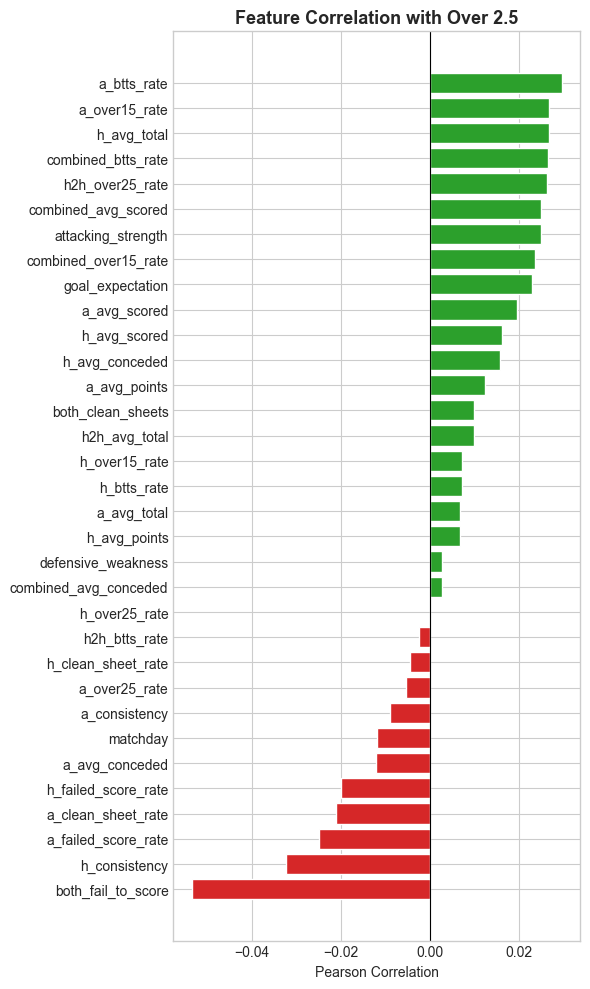

In [27]:
FEATURES = [c for c in feat_df.columns if c not in META_COLS]
corr = feat_df[FEATURES + ["over25"]].corr()["over25"].drop("over25").sort_values()

fig, ax = plt.subplots(figsize=(6, 10))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Over 2.5", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


## 🤖 Step 5 — Train Over/Under 2.5 Model

In [28]:
def train_models(feat_df):
    feat_df  = feat_df.dropna(subset=["over25"])
    FEATURES = [c for c in feat_df.columns if c not in META_COLS]
    X, y     = feat_df[FEATURES], feat_df["over25"]
    imb      = (y==0).sum() / max((y==1).sum(), 1)

    print(f"Dataset : {len(feat_df)} matches | {len(FEATURES)} features")
    print(f"Over 2.5: {y.mean():.1%}  |  Under 2.5: {(1-y.mean()):.1%}\n")

    models = {
        "Logistic Regression": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scl", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, C=0.1, class_weight="balanced"))
        ]),
        "Gradient Boosting": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", GradientBoostingClassifier(
                n_estimators=300, max_depth=3, learning_rate=0.03,
                subsample=0.8, random_state=42))
        ]),
        "XGBoost": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", xgb.XGBClassifier(
                n_estimators=300, max_depth=4, learning_rate=0.03,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=imb, eval_metric="logloss",
                random_state=42, verbosity=0))
        ]),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results, best_model, best_auc = {}, None, 0

    for name, model in models.items():
        acc  = cross_val_score(model, X, y, cv=cv, scoring="accuracy").mean()
        auc  = cross_val_score(model, X, y, cv=cv, scoring="roc_auc").mean()
        f1   = cross_val_score(model, X, y, cv=cv, scoring="f1").mean()
        probs = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:,1]
        brier = brier_score_loss(y, probs)
        results[name] = {"Accuracy":acc, "ROC-AUC":auc, "F1":f1, "Brier":brier, "probs":probs}
        print(f"  {name:22s} → Acc: {acc:.3f} | AUC: {auc:.3f} | F1: {f1:.3f} | Brier: {brier:.3f}")
        if auc > best_auc:
            best_auc, best_model = auc, (name, model)

    print(f"\n✅ Best: {best_model[0]} (AUC = {best_auc:.3f})")
    best_model[1].fit(X, y)
    print("\nClassification Report:")
    print(classification_report(y, best_model[1].predict(X),
                                  target_names=["Under 2.5","Over 2.5"]))
    return best_model[1], FEATURES, results, y

ou_model, ou_features, cv_results, y_true = train_models(feat_df)


Dataset : 1084 matches | 33 features
Over 2.5: 58.9%  |  Under 2.5: 41.1%

  Logistic Regression    → Acc: 0.492 | AUC: 0.480 | F1: 0.540 | Brier: 0.256
  Gradient Boosting      → Acc: 0.551 | AUC: 0.512 | F1: 0.672 | Brier: 0.254
  XGBoost                → Acc: 0.536 | AUC: 0.515 | F1: 0.604 | Brier: 0.261

✅ Best: XGBoost (AUC = 0.515)

Classification Report:
              precision    recall  f1-score   support

   Under 2.5       0.87      0.94      0.91       445
    Over 2.5       0.96      0.90      0.93       639

    accuracy                           0.92      1084
   macro avg       0.92      0.92      0.92      1084
weighted avg       0.92      0.92      0.92      1084



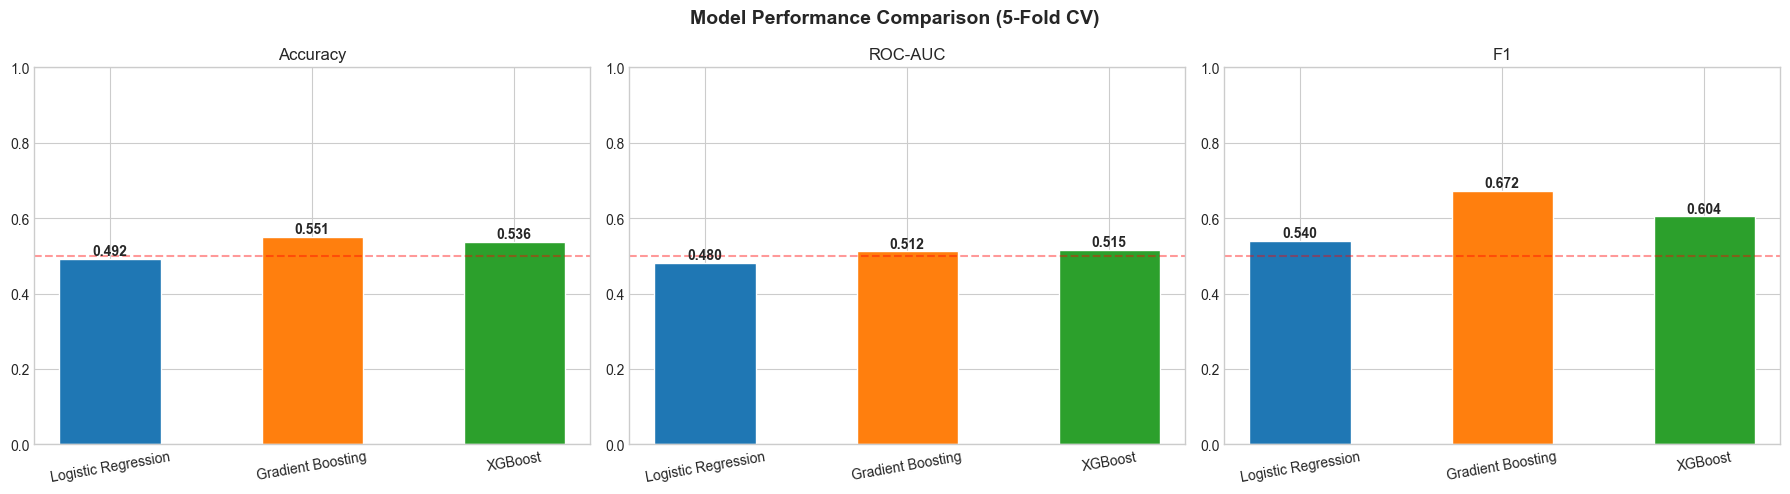

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Performance Comparison (5-Fold CV)", fontsize=14, fontweight="bold")

metrics = ["Accuracy", "ROC-AUC", "F1"]
model_names = list(cv_results.keys())

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    vals = [cv_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=PALETTE[:3], edgecolor="white", width=0.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4, label="Baseline")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.3f}",
                ha="center", fontsize=10, fontweight="bold")
    ax.set_xticklabels(model_names, rotation=10)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


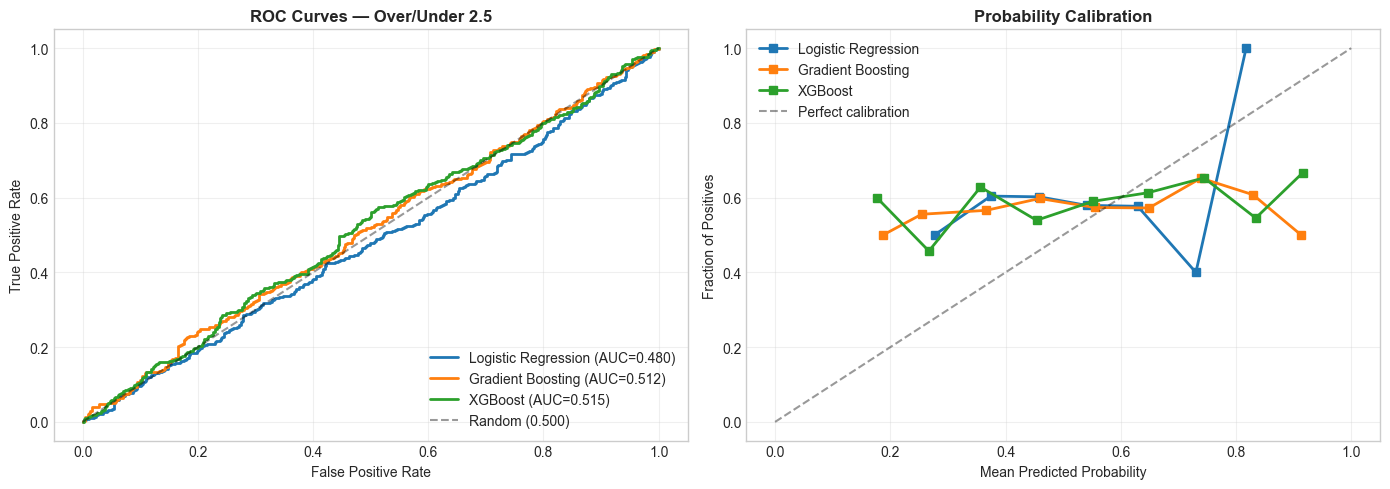

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
ax = axes[0]
for i, (name, res) in enumerate(cv_results.items()):
    fpr, tpr, _ = roc_curve(y_true, res["probs"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['ROC-AUC']:.3f})",
            color=PALETTE[i], linewidth=2)
ax.plot([0,1],[0,1],"k--", alpha=0.4, label="Random (0.500)")
ax.set_title("ROC Curves — Over/Under 2.5", fontsize=12, fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)

# Calibration plot
ax = axes[1]
for i, (name, res) in enumerate(cv_results.items()):
    frac_pos, mean_pred = calibration_curve(y_true, res["probs"], n_bins=10)
    ax.plot(mean_pred, frac_pos, "s-", label=name, color=PALETTE[i], linewidth=2)
ax.plot([0,1],[0,1],"k--", alpha=0.4, label="Perfect calibration")
ax.set_title("Probability Calibration", fontsize=12, fontweight="bold")
ax.set_xlabel("Mean Predicted Probability"); ax.set_ylabel("Fraction of Positives")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_calibration.png", dpi=150, bbox_inches="tight")
plt.show()


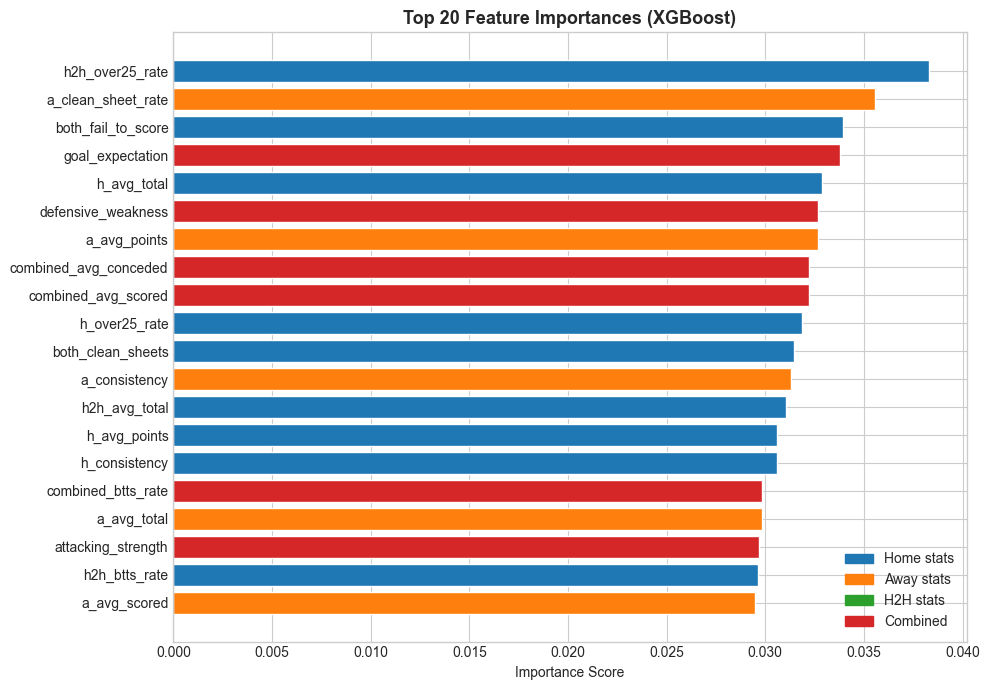

In [31]:
try:
    clf = ou_model.named_steps["clf"]
    imp = pd.Series(clf.feature_importances_, index=ou_features).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 7))
    top20 = imp.head(20)
    colors_fi = [PALETTE[0] if "h_" in i else
                 PALETTE[1] if "a_" in i else
                 PALETTE[2] if "h2h" in i else PALETTE[3] for i in top20.index]
    ax.barh(top20.index[::-1], top20.values[::-1], color=colors_fi[::-1], edgecolor="white")
    ax.set_title("Top 20 Feature Importances (XGBoost)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance Score")

    patches = [mpatches.Patch(color=PALETTE[0], label="Home stats"),
               mpatches.Patch(color=PALETTE[1], label="Away stats"),
               mpatches.Patch(color=PALETTE[2], label="H2H stats"),
               mpatches.Patch(color=PALETTE[3], label="Combined")]
    ax.legend(handles=patches, loc="lower right")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"Feature importance not available: {e}")


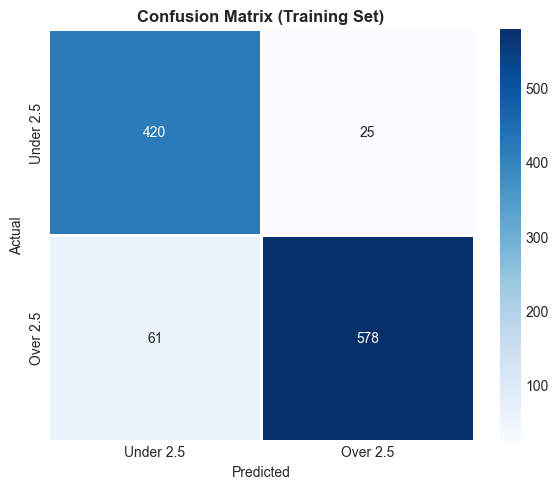

In [32]:
FEATURES_LIST = [c for c in feat_df.columns if c not in META_COLS]
y_pred = ou_model.predict(feat_df[FEATURES_LIST])
cm = confusion_matrix(feat_df["over25"], y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Under 2.5","Over 2.5"],
            yticklabels=["Under 2.5","Over 2.5"],
            linewidths=1, linecolor="white")
ax.set_title("Confusion Matrix (Training Set)", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 🏆 Step 6 — Train Outcome Model (Win / Draw / Loss)

Outcome model (3-class) → CV Accuracy: 0.458
              precision    recall  f1-score   support

    Away Win       0.88      0.88      0.88       357
        Draw       0.98      0.77      0.86       261
    Home Win       0.85      0.95      0.90       466

    accuracy                           0.88      1084
   macro avg       0.90      0.87      0.88      1084
weighted avg       0.89      0.88      0.88      1084



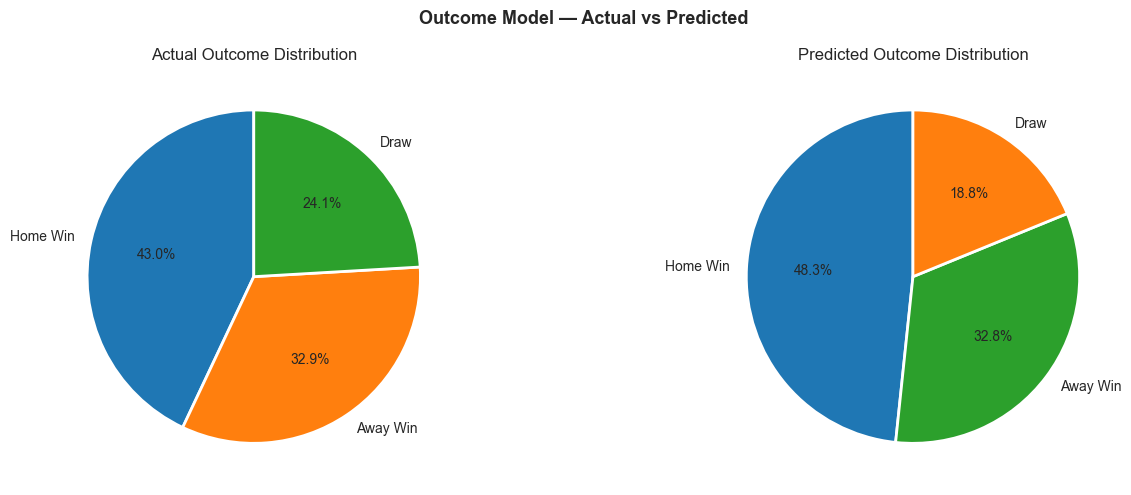

In [33]:
def train_outcome_model(feat_df):
    feat_df = feat_df.dropna(subset=["winner"]).copy()
    feat_df["result_code"] = feat_df["winner"].map({"HOME_TEAM":2,"DRAW":1,"AWAY_TEAM":0})
    feat_df = feat_df.dropna(subset=["result_code"])
    FEATURES = [c for c in feat_df.columns if c not in META_COLS | {"result_code"}]
    X, y = feat_df[FEATURES], feat_df["result_code"].astype(int)

    model = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8,
            objective="multi:softprob", num_class=3,
            eval_metric="mlogloss", random_state=42, verbosity=0,
        ))
    ])
    cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    acc = cross_val_score(model, X, y, cv=cv, scoring="accuracy").mean()
    print(f"Outcome model (3-class) → CV Accuracy: {acc:.3f}")
    model.fit(X, y)
    print(classification_report(y, model.predict(X),
                                  target_names=["Away Win","Draw","Home Win"]))

    # Outcome distribution chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    outcome_counts = feat_df["winner"].value_counts()
    axes[0].pie(outcome_counts, labels=["Home Win","Away Win","Draw"],
                autopct="%1.1f%%", colors=[PALETTE[0],PALETTE[1],PALETTE[2]],
                startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
    axes[0].set_title("Actual Outcome Distribution")

    y_pred_out = model.predict(X)
    pred_counts = pd.Series(y_pred_out).map({2:"Home Win",1:"Draw",0:"Away Win"}).value_counts()
    axes[1].pie(pred_counts, labels=pred_counts.index, autopct="%1.1f%%",
                colors=[PALETTE[0],PALETTE[2],PALETTE[1]],
                startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
    axes[1].set_title("Predicted Outcome Distribution")
    plt.suptitle("Outcome Model — Actual vs Predicted", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("outcome_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    return model, FEATURES

outcome_model, outcome_features = train_outcome_model(feat_df)


## 📈 Step 7 — Team Statistics Dashboard

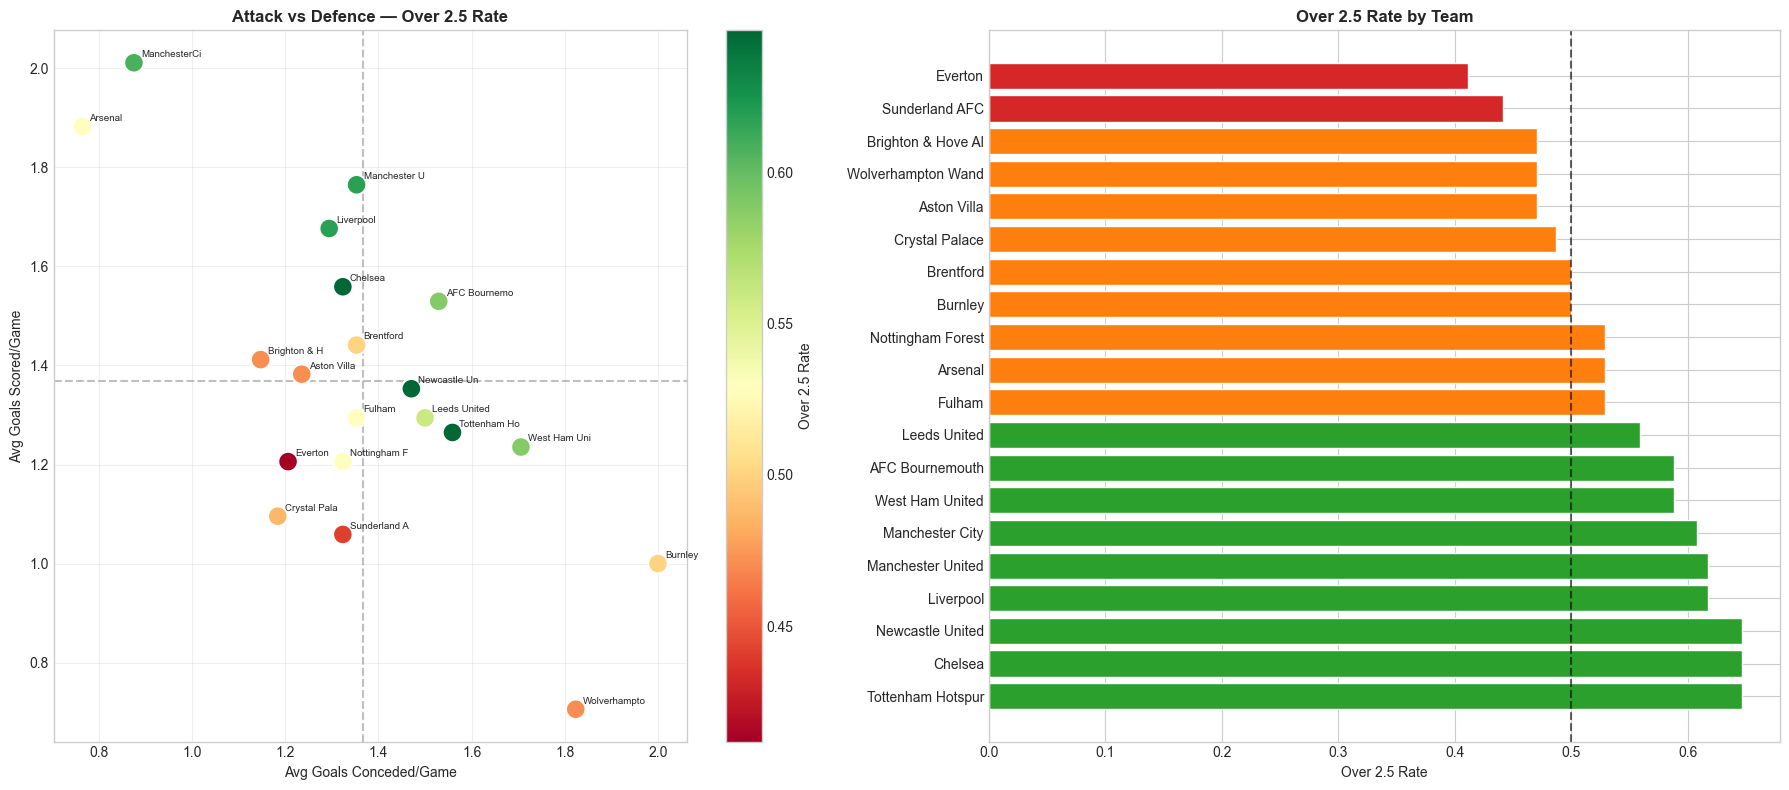

In [34]:
# Compute team-level aggregates from the last season
last_season = df[df["season"] == df["season"].max()].copy()

home_stats = last_season.groupby("home").agg(
    h_goals_scored=("home_score","mean"),
    h_goals_conceded=("away_score","mean"),
    h_over25=("over25","mean"),
    h_games=("date","count")
).reset_index().rename(columns={"home":"team"})

away_stats = last_season.groupby("away").agg(
    a_goals_scored=("away_score","mean"),
    a_goals_conceded=("home_score","mean"),
    a_over25=("over25","mean"),
    a_games=("date","count")
).reset_index().rename(columns={"away":"team"})

team_stats = home_stats.merge(away_stats, on="team")
team_stats["avg_scored"]   = (team_stats["h_goals_scored"] + team_stats["a_goals_scored"]) / 2
team_stats["avg_conceded"] = (team_stats["h_goals_conceded"] + team_stats["a_goals_conceded"]) / 2
team_stats["over25_rate"]  = (team_stats["h_over25"] + team_stats["a_over25"]) / 2
team_stats = team_stats.sort_values("over25_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Scatter: goals scored vs conceded
ax = axes[0]
scatter = ax.scatter(team_stats["avg_conceded"], team_stats["avg_scored"],
                     c=team_stats["over25_rate"], cmap="RdYlGn",
                     s=200, edgecolors="white", linewidth=1.5, zorder=3)
for _, row in team_stats.iterrows():
    ax.annotate(row["team"].replace(" FC","").replace(" City","City")[:12],
                (row["avg_conceded"], row["avg_scored"]),
                textcoords="offset points", xytext=(5, 4), fontsize=7)
ax.axhline(team_stats["avg_scored"].mean(), color="gray", linestyle="--", alpha=0.5)
ax.axvline(team_stats["avg_conceded"].mean(), color="gray", linestyle="--", alpha=0.5)
plt.colorbar(scatter, ax=ax, label="Over 2.5 Rate")
ax.set_title("Attack vs Defence — Over 2.5 Rate", fontsize=12, fontweight="bold")
ax.set_xlabel("Avg Goals Conceded/Game"); ax.set_ylabel("Avg Goals Scored/Game")
ax.grid(True, alpha=0.3)

# Bar: Over 2.5 rate by team
ax = axes[1]
bar_colors = ["#2ca02c" if v > 0.55 else "#ff7f0e" if v > 0.45 else "#d62728"
              for v in team_stats["over25_rate"]]
ax.barh(team_stats["team"].str.replace(" FC","").str[:18],
        team_stats["over25_rate"], color=bar_colors, edgecolor="white")
ax.axvline(0.5, color="black", linestyle="--", alpha=0.6, linewidth=1.5)
ax.set_title("Over 2.5 Rate by Team", fontsize=12, fontweight="bold")
ax.set_xlabel("Over 2.5 Rate")

plt.tight_layout()
plt.savefig("team_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


## 🎯 Step 8 — Predict Next Match

In [35]:
def predict_next_match(
    ou_model, ou_features,
    outcome_model, outcome_features,
    df, home_team, away_team, matchday=35,
):
    today = pd.Timestamp.today()
    h = rolling_team_stats(df, home_team, today, n=N_FORM)
    a = rolling_team_stats(df, away_team, today, n=N_FORM)

    if h is None:
        print(f"❌ No history for '{home_team}'.")
        print("Teams:", sorted(df["home"].unique().tolist()))
        return
    if a is None:
        print(f"❌ No history for '{away_team}'.")
        print("Teams:", sorted(df["home"].unique().tolist()))
        return

    h2h = df[
        (((df["home"]==home_team)&(df["away"]==away_team))|
         ((df["home"]==away_team)&(df["away"]==home_team)))
    ].tail(6)

    row = {
        "h_avg_scored":h["avg_scored"],"h_avg_conceded":h["avg_conceded"],
        "h_avg_total":h["avg_total"],"h_over25_rate":h["over25_rate"],
        "h_over15_rate":h["over15_rate"],"h_avg_points":h["avg_points"],
        "h_btts_rate":h["btts_rate"],"h_clean_sheet_rate":h["clean_sheet_rate"],
        "h_failed_score_rate":h["failed_score_rate"],"h_consistency":h["scoring_consistency"],
        "a_avg_scored":a["avg_scored"],"a_avg_conceded":a["avg_conceded"],
        "a_avg_total":a["avg_total"],"a_over25_rate":a["over25_rate"],
        "a_over15_rate":a["over15_rate"],"a_avg_points":a["avg_points"],
        "a_btts_rate":a["btts_rate"],"a_clean_sheet_rate":a["clean_sheet_rate"],
        "a_failed_score_rate":a["failed_score_rate"],"a_consistency":a["scoring_consistency"],
        "combined_avg_scored":h["avg_scored"]+a["avg_scored"],
        "combined_avg_conceded":h["avg_conceded"]+a["avg_conceded"],
        "goal_expectation":h["avg_scored"]+a["avg_scored"]+h["avg_conceded"]+a["avg_conceded"],
        "combined_btts_rate":h["btts_rate"]+a["btts_rate"],
        "defensive_weakness":h["avg_conceded"]+a["avg_conceded"],
        "attacking_strength":h["avg_scored"]+a["avg_scored"],
        "combined_over15_rate":h["over15_rate"]+a["over15_rate"],
        "both_clean_sheets":h["clean_sheet_rate"]*a["clean_sheet_rate"],
        "both_fail_to_score":h["failed_score_rate"]*a["failed_score_rate"],
        "h2h_avg_total":h2h["total_goals"].mean() if len(h2h)>0 else 2.5,
        "h2h_over25_rate":(h2h["total_goals"]>2.5).mean() if len(h2h)>0 else 0.5,
        "h2h_btts_rate":((h2h["home_score"]>0)&(h2h["away_score"]>0)).mean()
                          if len(h2h)>0 else 0.5,
        "matchday":matchday,
    }

    X_ou  = pd.DataFrame([row])[ou_features]
    p_ou  = ou_model.predict_proba(X_ou)[0]
    X_res = pd.DataFrame([row])[outcome_features]
    p_res = outcome_model.predict_proba(X_res)[0]  # [Away, Draw, Home]

    ou_label  = "⚽ OVER 2.5" if p_ou[1] >= 0.5 else "🔒 UNDER 2.5"
    outcomes = [
        (f"🏠 {home_team[:18]} Win", p_res[2]),
        ("🤝 Draw",                  p_res[1]),
        (f"✈️  {away_team[:18]} Win", p_res[0]),
    ]

    # ── Prediction Card ──────────────────────────────────────────
    print(f"\n{'═'*52}")
    print(f"  {home_team}  vs  {away_team}")
    print(f"  Matchday {matchday}")
    print(f"  {'─'*48}")
    print(f"\n  RESULT")
    for label, prob in sorted(outcomes, key=lambda x: -x[1]):
        print(f"  {label:<28} {prob:.1%}  {'█'*int(prob*24)}")
    print(f"\n  GOALS  →  {ou_label}")
    print(f"  Over 2.5   {p_ou[1]:.1%}  {'█'*int(p_ou[1]*24)}")
    print(f"  Under 2.5  {p_ou[0]:.1%}  {'█'*int(p_ou[0]*24)}")
    print(f"\n  FORM (last {N_FORM})")
    print(f"  {home_team[:22]:22s}  scored {h['avg_scored']:.2f}  conceded {h['avg_conceded']:.2f}  BTTS {h['btts_rate']:.0%}")
    print(f"  {away_team[:22]:22s}  scored {a['avg_scored']:.2f}  conceded {a['avg_conceded']:.2f}  BTTS {a['btts_rate']:.0%}")
    if len(h2h) > 0:
        h_wins = ((h2h["home"]==home_team)&(h2h["winner"]=="HOME_TEAM")).sum() + \
                 ((h2h["away"]==home_team)&(h2h["winner"]=="AWAY_TEAM")).sum()
        a_wins = len(h2h) - h_wins - (h2h["winner"]=="DRAW").sum()
        print(f"\n  H2H (last {len(h2h)})  {h_wins}W-{(h2h['winner']=='DRAW').sum()}D-{a_wins}W  Avg goals: {h2h['total_goals'].mean():.2f}")
    best = max(outcomes, key=lambda x: x[1])
    print(f"\n  💰 KELLY HINT: '{best[0].strip()}' if bookie implied < {best[1]:.1%}")
    print(f"{'═'*52}")

    # ── Visualize prediction ──────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"{home_team}  vs  {away_team} — MD{matchday}", fontsize=13, fontweight="bold")

    # Result donut
    ax = axes[0]
    vals = [p_res[2], p_res[1], p_res[0]]
    labels = [f"Home Win\n{p_res[2]:.1%}", f"Draw\n{p_res[1]:.1%}", f"Away Win\n{p_res[0]:.1%}"]
    wedges, texts = ax.pie(vals, labels=labels, colors=[PALETTE[0],PALETTE[2],PALETTE[1]],
                            startangle=90, wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2))
    ax.set_title("Result Probabilities")

    # Over/Under bar
    ax = axes[1]
    bars = ax.bar(["Under 2.5","Over 2.5"], [p_ou[0], p_ou[1]],
                  color=[PALETTE[3], PALETTE[2]], edgecolor="white", width=0.5)
    ax.axhline(0.5, color="black", linestyle="--", alpha=0.4)
    for bar, val in zip(bars, [p_ou[0],p_ou[1]]):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.1%}",
                ha="center", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1); ax.set_title("Over/Under 2.5 Probability")
    ax.set_ylabel("Probability")

    # Form radar (simplified bar chart)
    ax = axes[2]
    metrics_h = [h["avg_scored"], h["avg_conceded"], h["btts_rate"]*3,
                 h["clean_sheet_rate"]*3, h["avg_points"]]
    metrics_a = [a["avg_scored"], a["avg_conceded"], a["btts_rate"]*3,
                 a["clean_sheet_rate"]*3, a["avg_points"]]
    labels_r  = ["Scored","Conceded","BTTS×3","CS×3","Avg Pts"]
    x = np.arange(len(labels_r))
    ax.bar(x-0.2, metrics_h, width=0.38, label=home_team[:14], color=PALETTE[0], edgecolor="white")
    ax.bar(x+0.2, metrics_a, width=0.38, label=away_team[:14], color=PALETTE[1], edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(labels_r, fontsize=9)
    ax.set_title(f"Form Comparison (last {N_FORM})"); ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("prediction_card.png", dpi=150, bbox_inches="tight")
    plt.show()

print("✅ Prediction function ready")


✅ Prediction function ready


## ▶️ Step 9 — Run Your Prediction

In [36]:
# First: check exact team names in your data
print("Available teams:")
print(sorted(df["home"].unique().tolist()))


Available teams:
['AFC Bournemouth', 'Arsenal FC', 'Aston Villa FC', 'Brentford FC', 'Brighton & Hove Albion FC', 'Burnley FC', 'Chelsea FC', 'Crystal Palace FC', 'Everton FC', 'Fulham FC', 'Ipswich Town FC', 'Leeds United FC', 'Leicester City FC', 'Liverpool FC', 'Luton Town FC', 'Manchester City FC', 'Manchester United FC', 'Newcastle United FC', 'Nottingham Forest FC', 'Sheffield United FC', 'Southampton FC', 'Sunderland AFC', 'Tottenham Hotspur FC', 'West Ham United FC', 'Wolverhampton Wanderers FC']



════════════════════════════════════════════════════
  Arsenal FC  vs  Fulham FC
  Matchday 35
  ────────────────────────────────────────────────

  RESULT
  🤝 Draw                       38.5%  █████████
  🏠 Arsenal FC Win             36.3%  ████████
  ✈️  Fulham FC Win            25.2%  ██████

  GOALS  →  🔒 UNDER 2.5
  Over 2.5   45.4%  ██████████
  Under 2.5  54.6%  █████████████

  FORM (last 5)
  Arsenal FC              scored 1.20  conceded 0.80  BTTS 40%
  Fulham FC               scored 0.80  conceded 0.60  BTTS 20%

  H2H (last 5)  2W-2D-1W  Avg goals: 2.60

  💰 KELLY HINT: '🤝 Draw' if bookie implied < 38.5%
════════════════════════════════════════════════════


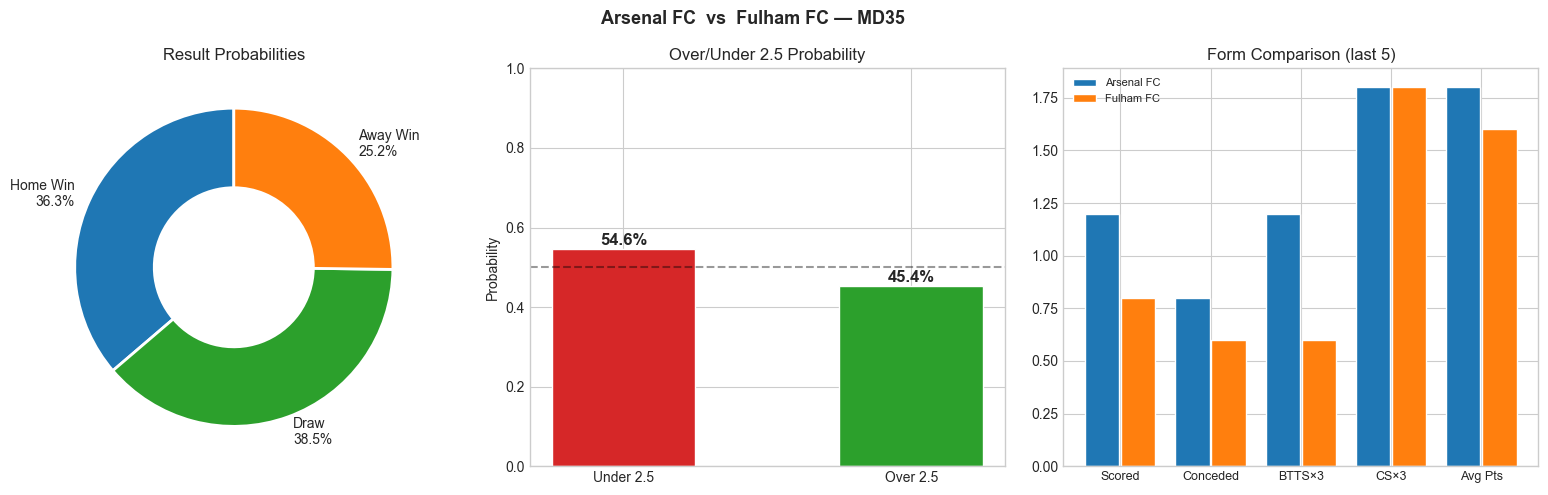

In [37]:
# ✏️ Change team names to match exactly what's printed above
predict_next_match(
    ou_model, ou_features,
    outcome_model, outcome_features,
    df,
    home_team = "Arsenal FC",     # ← exact name from list above
    away_team = "Fulham FC",      # ← exact name from list above
    matchday  = 35,
)


## 🔁 Step 10 — Backtest (Optional)

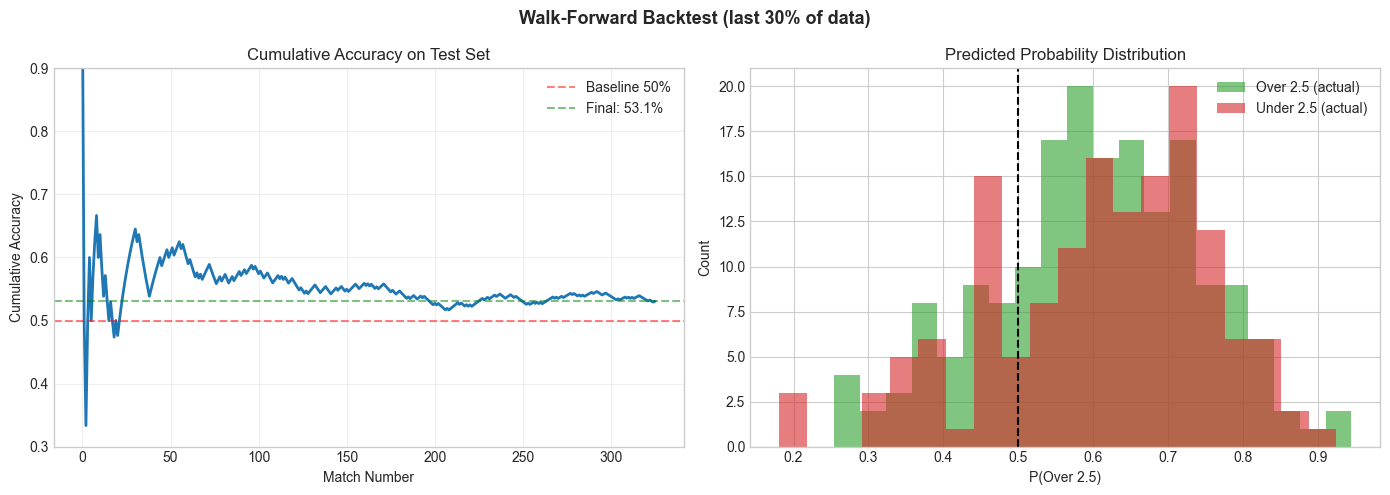


Backtest Results (326 matches)
  Accuracy : 0.531
  ROC-AUC  : 0.474
  Brier    : 0.276
              precision    recall  f1-score   support

   Under 2.5       0.47      0.24      0.32       148
    Over 2.5       0.55      0.77      0.64       178

    accuracy                           0.53       326
   macro avg       0.51      0.51      0.48       326
weighted avg       0.51      0.53      0.50       326



In [42]:
# Walk-forward backtest: train on first 70%, test on last 30%
feat_clean = feat_df.dropna(subset=["over25"]).sort_values("date").reset_index(drop=True)
FEATURES   = [c for c in feat_clean.columns if c not in META_COLS]
split      = int(len(feat_clean) * 0.70)

X_train, X_test = feat_clean[FEATURES][:split], feat_clean[FEATURES][split:]
y_train, y_test = feat_clean["over25"][:split],  feat_clean["over25"][split:]

from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy="median")
X_tr_imp = imp.fit_transform(X_train)
X_te_imp = imp.transform(X_test)

bt_model = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.03,
                               subsample=0.8, eval_metric="logloss",
                               random_state=42, verbosity=0)
bt_model.fit(X_tr_imp, y_train)
bt_probs = bt_model.predict_proba(X_te_imp)[:,1]
bt_preds = (bt_probs >= 0.5).astype(int)

# Cumulative accuracy
cumulative_acc = (bt_preds == y_test.values).cumsum() / (np.arange(len(y_test)) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Walk-Forward Backtest (last 30% of data)", fontsize=13, fontweight="bold")

# Cumulative accuracy
ax = axes[0]
ax.plot(cumulative_acc, color=PALETTE[0], linewidth=2)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Baseline 50%")
ax.axhline(cumulative_acc[-1], color="green", linestyle="--", alpha=0.5,
           label=f"Final: {cumulative_acc[-1]:.1%}")
ax.set_title("Cumulative Accuracy on Test Set")
ax.set_xlabel("Match Number"); ax.set_ylabel("Cumulative Accuracy")
ax.set_ylim(0.3, 0.9); ax.legend(); ax.grid(True, alpha=0.3)

# Probability distribution by actual outcome
ax = axes[1]
ax.hist(bt_probs[y_test==1], bins=20, alpha=0.6, color=PALETTE[2], label="Over 2.5 (actual)")
ax.hist(bt_probs[y_test==0], bins=20, alpha=0.6, color=PALETTE[3], label="Under 2.5 (actual)")
ax.axvline(0.5, color="black", linestyle="--")
ax.set_title("Predicted Probability Distribution")
ax.set_xlabel("P(Over 2.5)"); ax.set_ylabel("Count"); ax.legend()

plt.tight_layout()
plt.savefig("backtest.png", dpi=150, bbox_inches="tight")
plt.show()

from sklearn.metrics import accuracy_score
print(f"\nBacktest Results ({len(y_test)} matches)")
print(f"  Accuracy : {accuracy_score(y_test, bt_preds):.3f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, bt_probs):.3f}")
print(f"  Brier    : {brier_score_loss(y_test, bt_probs):.3f}")
print(classification_report(y_test, bt_preds, target_names=["Under 2.5","Over 2.5"]))


Past results don't guarantee future results. 

In this Jyputer notebook, I shared one of the tactics one can use to predict a O/U 2.5 for a specific match using the match data from the 3 previous seasons. 

To make it more accurate, more data like offensive and defensive behavior, history between teams, injuries etc can be also taken into account to predict better.